In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
path = r'/Users/pravinkumar/Downloads/enriched_aqi_dataset.csv'

In [6]:
df = pd.read_csv(path)

In [7]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,...,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,...,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,...,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,...,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,...,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,...,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10521 entries, 0 to 10520
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         10521 non-null  str    
 1   state           10521 non-null  str    
 2   city            10521 non-null  str    
 3   station         10521 non-null  str    
 4   last_update     10521 non-null  str    
 5   latitude        10521 non-null  float64
 6   longitude       10521 non-null  float64
 7   pollutant_id    10521 non-null  str    
 8   pollutant_min   10164 non-null  float64
 9   pollutant_max   10164 non-null  float64
 10  pollutant_avg   10164 non-null  float64
 11  AQI             10521 non-null  int64  
 12  AQI_Bucket      10521 non-null  str    
 13  Temperature_C   10521 non-null  float64
 14  Humidity_%      10521 non-null  float64
 15  Wind_Speed_kmh  10521 non-null  float64
 16  Year            10521 non-null  int64  
 17  Month           10521 non-null  int64  
 1

In [9]:
df['AQI'].head()

0    20
1    15
2     1
3    96
4    12
Name: AQI, dtype: int64

# Q1

In [10]:
aqi = df['AQI'].dropna()

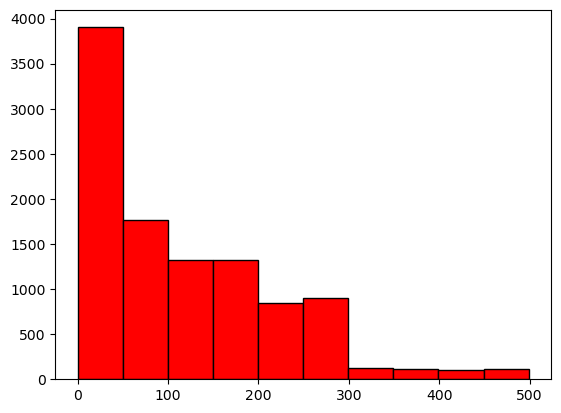

In [11]:
plt.hist(aqi, color='red', edgecolor= 'black', label= 'AQI DISTRIBUTION')
plt.show()

#### **Insights**
- Over all distribution of AQI is right skewed.

# Q2

In [12]:
# freq_pollutant = df['pollutant_id'].mode()

In [13]:
frequent_pollutant = df['pollutant_id'].value_counts()

In [14]:
print(frequent_pollutant)

pollutant_id
SO2      1555
NH3      1533
PM10     1517
NO2      1505
CO       1498
PM2.5    1496
OZONE    1417
Name: count, dtype: int64


In [15]:
x = frequent_pollutant.index
y = frequent_pollutant.values

<BarContainer object of 7 artists>

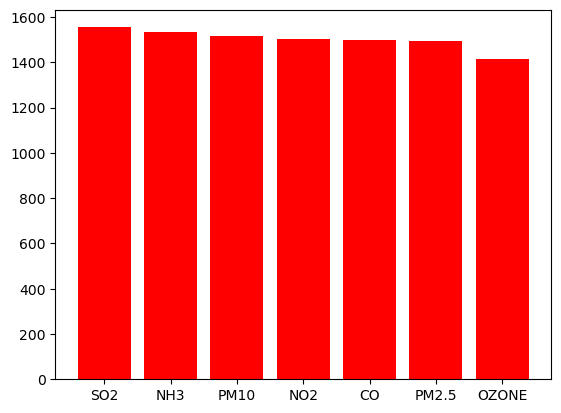

In [16]:
plt.bar(x,y, color='red')

#### **Insights**
- Most common pollutant is "SO2"
- Top three pollutant are "SO2", "NH3", "PM10".

In [17]:
## SO2 is the most frequently occured pollutant as a primary concern.

# Q3

In [18]:
df['Temperature_C'].describe().T

count    10521.000000
mean        27.584621
std          7.231523
min         15.000000
25%         21.300000
50%         27.600000
75%         33.900000
max         40.000000
Name: Temperature_C, dtype: float64

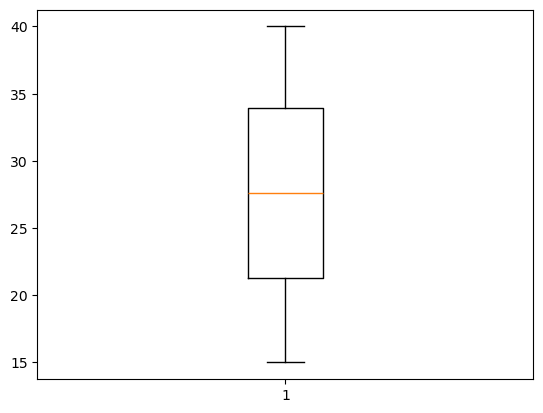

In [19]:
plt.boxplot(df['Temperature_C'])
plt.show()

#### **Insights**
- Typical temperature is between 20-30 degree celcius. There are no extreme outlier detected

In [20]:
## Typical temperature is between 20-30 degree celcius. There are no extreme outliers detected.

# Q4

In [21]:
aqi_category = df['AQI_Bucket'].value_counts()

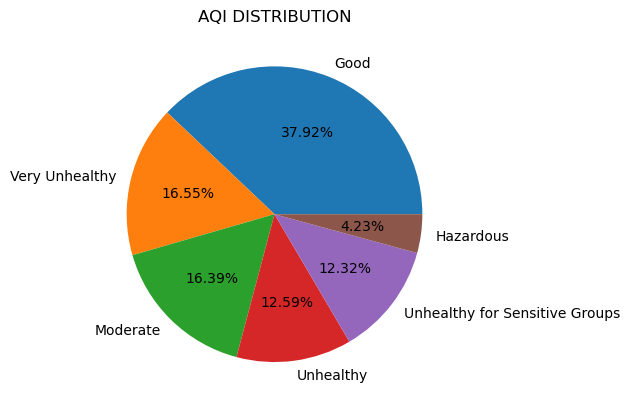

In [22]:
plt.pie(aqi_category.values, labels= aqi_category.index, autopct = '%1.2f%%')
plt.title("AQI DISTRIBUTION")
plt.show()


#### **Insights**
- 37.92% fall into "Good" category.
- 16.39% fall into "Moderate" category.
- 12.59% fall into "Unhealthy" category.
- 12.32% fall into "Unhealthy for Sensitive Groups" category.
- 16.55% fall into "Very Unhealthy" category.
- 4.23% fall into "Hazardous" category.

# Q5

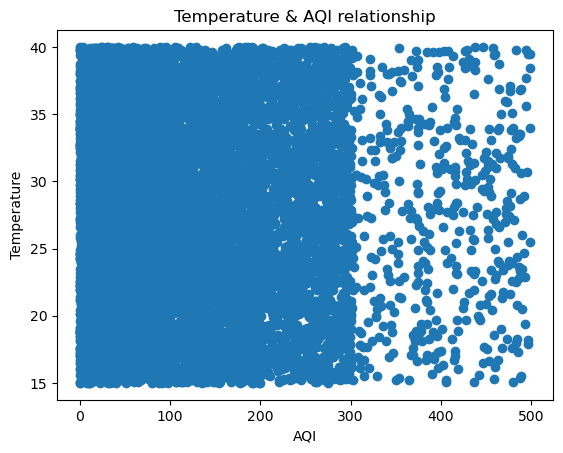

In [24]:
plt.scatter(df['AQI'],df['Temperature_C'])
plt.title("Temperature & AQI relationship")
plt.xlabel("AQI")
plt.ylabel("Temperature")
plt.show()

In [25]:
## There is no relationship found between temperature and AQI. Though AQI observation is dense below 300.

# Q6

In [26]:
high_aqi_state = df.groupby("state")['AQI'].mean().sort_values(ascending=False)

In [27]:
high_aqi_state

state
Sikkim               149.663968
Meghalaya            149.258503
Jammu and Kashmir    146.375000
Jharkhand            145.274262
Mizoram              138.161290
Tripura              137.801688
Chandigarh           137.684000
Tamil Nadu           135.890034
Kerala               135.301961
Uttarakhand          134.181102
Punjab               133.955932
Arunachal Pradesh    130.903614
Himachal Pradesh     129.650190
Nagaland             127.388664
Assam                127.085987
Chhattisgarh         126.897361
Puducherry           125.937778
Bihar                119.297297
Odisha               119.131285
Telangana            118.215385
Haryana              117.959368
Gujarat              117.873563
Madhya Pradesh       116.663391
Andhra Pradesh       113.427215
Karnataka            112.166667
Delhi                 99.439623
West Bengal           96.034759
Maharashtra           94.670630
Uttar Pradesh         93.324238
Rajasthan             81.332149
Name: AQI, dtype: float64

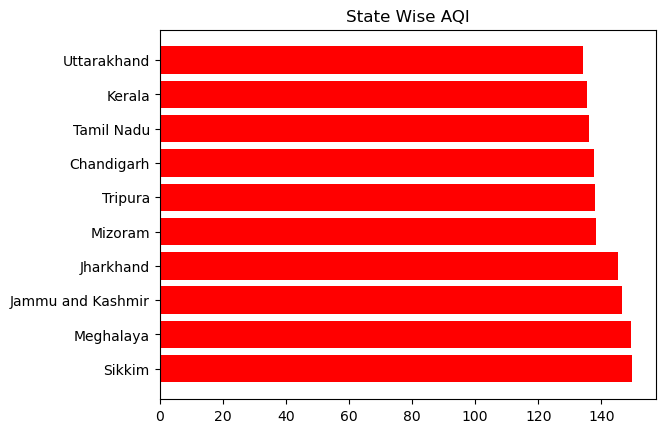

In [28]:
plt.barh(high_aqi_state.index[:10], high_aqi_state.values[:10], color= 'red')
plt.title('State Wise AQI')
plt.show()

In [29]:
## Sikkim experienced the highest average AQI.
## Top 4 states are very close to each other in terms of AQI. All 4 states have average AQI over 140.

In [30]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,...,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,...,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,...,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,...,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,...,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,...,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer


# Q7

In [31]:
hourly_aqi = df.groupby("Hour")['AQI'].mean()

Text(0.5, 1.0, 'Hourly AQI')

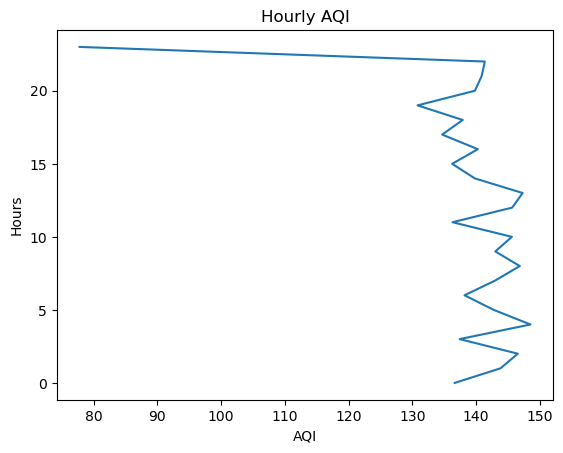

In [32]:
plt.plot(hourly_aqi.values, hourly_aqi.index)
plt.xlabel("AQI")
plt.ylabel("Hours")
plt.title("Hourly AQI")

# Q8

In [33]:
high_aqi_p = df.groupby("pollutant_id")['AQI'].mean().sort_values(ascending=False)

In [34]:
high_aqi_p

pollutant_id
PM10     127.359921
PM2.5    126.891711
NH3      123.926941
NO2      115.174086
SO2      113.933762
CO       111.489987
OZONE    108.288638
Name: AQI, dtype: float64

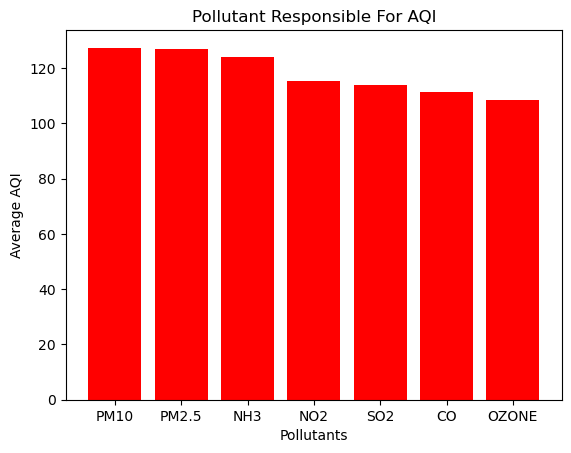

In [35]:
plt.bar(high_aqi_p.index, high_aqi_p.values, color='red')
plt.xlabel("Pollutants")
plt.ylabel("Average AQI")
plt.title("Pollutant Responsible For AQI")
plt.show()

In [36]:
## PM10 is associated with highest average AQI

# Q9

In [37]:
# aqi_correlation = df.groupby("Temperature_C")("Humidity_%")("Wind_Speed_kmh")['AQI']

In [38]:
columns = df[["AQI", "Temperature_C","Humidity_%","Wind_Speed_kmh"]]

correlation = columns.corr(method="pearson")

In [39]:
print(correlation)

                     AQI  Temperature_C  Humidity_%  Wind_Speed_kmh
AQI             1.000000       0.003898   -0.013977       -0.020544
Temperature_C   0.003898       1.000000   -0.008313       -0.003068
Humidity_%     -0.013977      -0.008313    1.000000       -0.014478
Wind_Speed_kmh -0.020544      -0.003068   -0.014478        1.000000


# Q10

In [40]:
df.groupby(["Season", "pollutant_id"])["AQI"].mean()

Season  pollutant_id
Autumn  CO              129.958678
        NH3             136.876068
        NO2             144.694779
        OZONE           151.272300
        PM10            132.971074
        PM2.5           142.739300
        SO2             133.738983
Spring  CO              141.141631
        NH3             138.785185
        NO2             144.763566
        OZONE           133.171946
        PM10            144.202952
        PM2.5           147.314607
        SO2             135.169291
Summer  CO               84.130051
        NH3             106.918421
        NO2              87.795071
        OZONE            78.961126
        PM10            116.463768
        PM2.5           108.269972
        SO2              91.637076
Winter  CO              156.038961
        NH3             145.802974
        NO2             142.154185
        OZONE           138.767932
        PM10            136.942857
        PM2.5           143.126016
        SO2             138.279167

# Q11

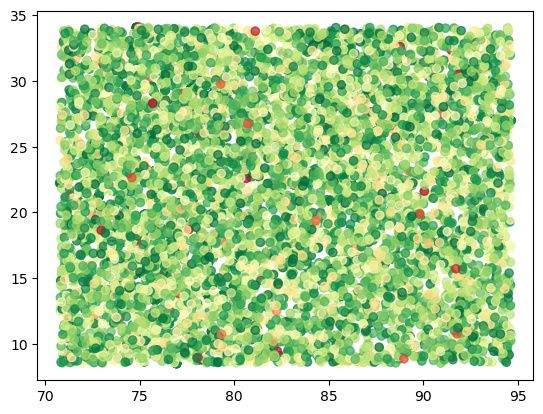

In [41]:
plt.scatter(df['longitude'], df['latitude'], c=df['AQI'],cmap="RdYlGn_r", alpha=0.7)

# Q12

In [42]:
top = df.groupby("state")['AQI'].mean().sort_values(ascending=False)[:3]

In [43]:
top

state
Sikkim               149.663968
Meghalaya            149.258503
Jammu and Kashmir    146.375000
Name: AQI, dtype: float64

In [44]:
new_df = df[df['state'].isin(top)]